In [87]:
import numpy as np
import random
from scipy.signal import lfilter
from IPython.display import Audio
import matplotlib.pyplot as plt

In [88]:
fs = 44100
f0 = 100

In [89]:
formants = {
    "a": {
      "freqs": [620,	1220,	2550,	3300,	4500],
      "bws": [80, 100, 140, 200, 250],
    },
    "e": {
      "freqs": [550, 2000, 2600, 3450, 4700],
      "bws": [50, 80, 100, 150, 200],
    },
    "i": {
      "freqs": [300, 2200, 3000, 3700, 5000],
      "bws": [60, 110, 130, 220, 270],
    },
    "o": {
      "freqs": [500, 800, 2500, 3200, 4300],
      "bws": [50, 80, 80, 150, 200],
    },
    "u": {
      "freqs": [300, 600, 2200, 3000, 4000],
      "bws": [50, 80, 100, 170, 220],
    },
    "y": {
      "freqs": [450, 1400, 2300, 3400, 4500],
      "bws": [70, 110, 120, 200, 250],
    },
    "w": {
        "freqs": [290, 610, 2150],
        "bws": [50, 80, 60],
    },
    "j": {
        "freqs": [260, 2070, 3020],
        "bws": [40, 250, 500],
    },
    "l": {
        "freqs": [310, 1050, 2880],
        "bws": [50, 100, 280],
    },
    "m": {
        "freqs": [250, 1000, 2200],
        "bws": [50, 80, 120],
        "anti_f": 800,
        "anti_bw": 150
    },
    "n": {
        "freqs": [300, 1500, 3500],
        "bws": [60, 90, 130],
        "anti_f": 1000,
        "anti_bw": 160
    },
    "ng": {
        "freqs": [350, 1800, 2800],
        "bws": [60, 100, 130],
        "anti_f": 1500,
        "anti_bw": 200
    },
    "t": {
        "freqs": [400, 1800, 2600],
        "bws": [50, 120, 250],
    },
    "k": {
        "freqs": [300, 2000, 2300],
        "bws": [50, 130, 220],
    },
    "p": {
        "freqs": [200, 800, 2000],
        "bws": [50, 90, 200],
    },
}

In [90]:
def one_band_filter(sig, F, BW, fs=fs):
  T = 1 / fs
  B = 2 * np.exp(-np.pi * BW * T) * np.cos(2* np.pi * F * T)
  C = -np.exp(-2 * np.pi * BW * T)
  A = 1 - B - C
  return lfilter([A], [1, -B, -C], sig)

In [91]:
def get_glottal_wave_period(T, fs):
  # функция, возвращающая один период глоттальной волны
  Tp = int(0.4 * T * fs)
  Tn = int(0.16 * T * fs)
  T_ = int(T * fs)

  fp = [3 * (t / Tp) ** 2 - 2 * (t / Tp) ** 3 for t in range(Tp)]
  fn = [1 - ((t - Tp) / Tn) ** 2 for t in range(Tp, Tp + Tn)]
  f0 = [0 for t in range(Tp + Tn, T_)]

  impulse = fp + fn + f0
  return np.array(impulse)

In [92]:
def get_glottal_wave(T, fs, duration, jitter=0.05, shimmer=0.05):
  # функция, возвращающая глоттальную волну нужной длительности
  glottal_wave = []

  period_num = int(duration / T)

  for i in range(period_num):
      T_new = T + T * jitter * random.random()
      new_impulse = get_glottal_wave_period(T_new, fs) * (1 + shimmer * random.random())
      glottal_wave.extend(new_impulse)

  return glottal_wave

In [93]:
def antiformant_filter(sig, F, BW):
    T = 1 / fs
    B = -2 * np.exp(-np.pi * BW * T) * np.cos(2* np.pi * F * T)
    C = np.exp(-2 * np.pi * BW * T)
    A = 1
    return lfilter([A, B, C], [1], sig)

In [94]:
nasals = ("m", "n", "ng")

In [95]:
def get_sonorant_sound(phon, fs, f0, duration, make_envelope=False):
    source = get_glottal_wave(1 / f0, fs, duration)

    formant_freqs = formants[phon]["freqs"]
    bws = formants[phon]["bws"]

    result = source
    for freq, bw in zip(formant_freqs, bws):
      result = one_band_filter(result, freq, bw, fs)

    if phon in nasals:
      result = antiformant_filter(result, formants[phon]["anti_f"], formants[phon]["anti_bw"])

    if make_envelope:
      start = int(0.04 * fs)
      end = int(0.05 * fs)

      envelope = np.ones_like(result)
      envelope[:start] = np.linspace(0, 1, start)
      envelope[-end:] = np.linspace(1, 0, end)
      result *= envelope

    return result

In [96]:
def make_morph_sound(first_phon, second_phon, number_of_periods, f0, fs):
  result = []

  morph_formants = []
  morph_bws = []
  first_formants = formants[first_phon]["freqs"]
  sec_formants = formants[second_phon]["freqs"]

  first_bws = formants[first_phon]["bws"]
  sec_bws = formants[second_phon]["bws"]

  for i in range(number_of_periods):
    morph_formants.append([])
    morph_bws.append([])
    for j in range(min(len(first_formants), len(sec_formants))):
      morph_formants[-1].append(first_formants[j] + (i + 1) * (sec_formants[j] - first_formants[j]) / (number_of_periods + 1))
      morph_bws[-1].append(first_bws[j] + (i + 1) * (sec_bws[j] - first_bws[j]) / (number_of_periods + 1))

  for i in range(number_of_periods):
      period = get_glottal_wave_period(1/f0, fs)
      for f, bw, in zip(morph_formants[i], morph_bws[i]):
        period = one_band_filter(period, f, bw, fs)

      result = np.concatenate((result, period))

  return result

<h2>Смычные согласные</h2>

Задание. Напишите функцию, возвращающую смычный согласный нужной длительности. Примите длительность взрыва за 0.01 секунды, а длительность смычки передавайте как аргумент функции.

1. Сгенерируйте смычку + шум (нули + белый шум длительностью 0.01)
2. Если смычный звонкий, добавьте озвончение (как это делалось с щелевыми)
3. Отфильтруйте получившийся результат по формантным частотам из словаря formants
4. Смоделируйте локусы - переход в несколько периодов от смычного к следующему звуку (функция make_morph_sound). Если дальше пауза или другой смычный, пропустите этот шаг. Следующий согласный задается аргументом next_phon, если переходный участок не нужен, принимает значение False
5. Сложите со смычкой

In [97]:
def get_stop_sound(phon, stop_duration, burst_duration, fs, f0, is_voiced=False, next_phon=False):
  total_duration = stop_duration + burst_duration
  t = np.linspace(0, total_duration, int(total_duration * fs))

  source = np.concatenate((np.zeros(int(stop_duration * fs)), np.random.normal(0, 1.0, int(burst_duration * fs))))

  if is_voiced:
    voiced = np.sin(2 * np.pi * f0 * t)
    voiced += 0.5 * np.sin(2 * np.pi * 2 * f0 * t)
    voiced += 0.2 * np.sin(2 * np.pi * 3 * f0 * t)
    source += voiced

  if next_phon and phon == "k":
    k_formants = formants[phon]["freqs"]
    k_formants[1] = formants[next_phon]["freqs"][1]
    for f, bw in zip(k_formants, formants[phon]["bws"]):
      source = one_band_filter(source, f, bw, fs)
    return source

  for f, bw in zip(formants[phon]["freqs"], formants[phon]["bws"]):
    source = one_band_filter(source, f, bw, fs)

  if next_phon:
    source = np.concatenate((source, make_morph_sound(phon, next_phon, 3, f0, fs)))

  return source

In [98]:
t = get_stop_sound("t", 0.1, 0.01, fs, f0, is_voiced=False)

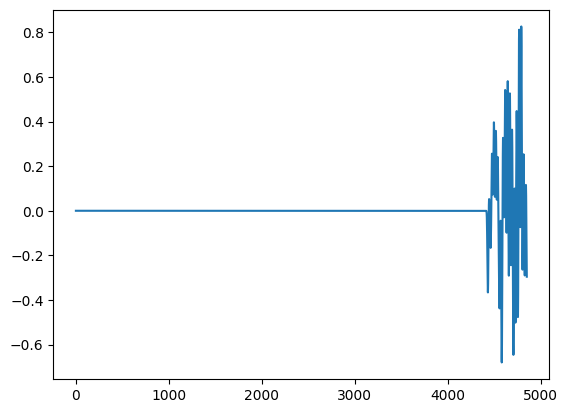

In [99]:
plt.plot(t)

In [100]:
tata = np.concatenate((
    0.3 * get_stop_sound("t", 0.15, 0.01, fs, f0),
    get_sonorant_sound("a", fs, f0, 0.3, make_envelope=True),
    0.3 * get_stop_sound("t", 0.15, 0.01, fs, f0),
    get_sonorant_sound("a", fs, f0, 0.2, make_envelope=True),
))

In [101]:
Audio(tata, rate=fs)

In [102]:
dada = np.concatenate((
    0.1 * get_stop_sound("t", 0.15, 0.01, fs, f0, is_voiced=True),
    get_sonorant_sound("a", fs, f0, 0.3, make_envelope=True),
    0.1 * get_stop_sound("t", 0.15, 0.01, fs, f0, is_voiced=True),
    get_sonorant_sound("a", fs, f0, 0.2, make_envelope=True),
))

In [103]:
Audio(dada, rate=fs)

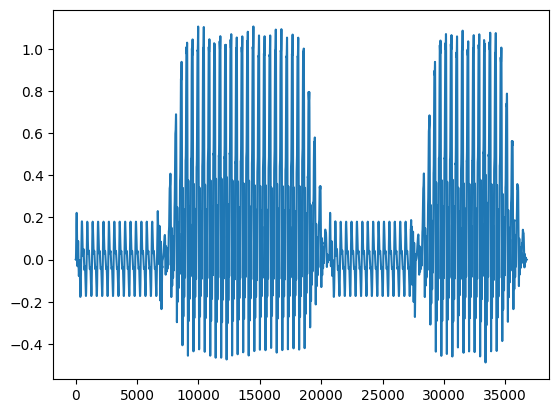

In [104]:
plt.plot(dada)

In [105]:
papa = np.concatenate((
    get_stop_sound("p", 0.1, 0.01, fs, f0),
    get_sonorant_sound("a", fs, f0, 0.3),
    get_stop_sound("p", 0.1, 0.01, fs, f0),
    get_sonorant_sound("a", fs, f0, 0.2),
))

In [106]:
Audio(papa, rate=fs)

In [107]:
kaka = np.concatenate((
    0.3 * get_stop_sound("k", 0.1, 0.02, fs, f0),
    get_sonorant_sound("a", fs, f0, 0.3),
    0.3 * get_stop_sound("k", 0.1, 0.02, fs, f0),
    get_sonorant_sound("a", fs, f0, 0.2),
))

In [108]:
Audio(kaka, rate=fs)

<h2>Палатализация</h2>

Задание: соберите слово "мята"

In [124]:
myata = np.concatenate((
    0.6 * get_sonorant_sound("m", fs, f0, 0.3),
    0.7 * make_morph_sound("m", "i", 3, f0, fs),
    0.8 * make_morph_sound("i", "a", 3, f0, fs),
    get_sonorant_sound("a", fs, f0, 0.25),
    0.1 * get_stop_sound("t", 0.1, 0.01, fs, f0),
    0.3 * get_sonorant_sound("a", fs, f0, 0.2),
))

In [125]:
Audio(myata, rate=fs)